In [1]:
import numpy as np
import pandas as pd
import stumpy
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv('~/Jlab/Sensor data/Original Data/2018_OUTPUT_VARS.1h.csv')
df.head(5)

,Unnamed: 0,DATE,IBC1H04CRCUR2,IBC2C24CRCUR3,IBC3H00CRCUR4,BLA,MMSHLAE,MMSHLCE,haBDSPOS,rad44_p1,...,RBM06_DsRt_ME,RBM07_DsRt_HE,RBM07_DsRt_LE,RBM07_DsRt_ME,RBM08_DsRt_HE,RBM08_DsRt_LE,RBM08_DsRt_ME,RBM09_DsRt_HE,RBM09_DsRt_LE,RBM09_DsRt_ME
0,0,1/1/2018 0:00,0.000025,0.000000,0.0,0.0,2218.48999,2218.48999,0,0.007,...,0.0,7.198692,1.256136,2.233301,6.686333,1.060630,1.809135,6.615573,0.950947,1.746011
1,1,1/1/2018 1:00,0.000000,0.000417,0.0,0.0,2218.48999,2218.48999,0,0.002,...,0.0,7.217848,1.260443,2.246833,6.688757,1.071017,1.801422,6.667002,0.957450,1.739011
2,2,1/1/2018 2:00,0.000000,0.000000,0.0,0.0,2218.48999,2218.48999,0,0.013,...,0.0,7.171417,1.266648,2.252588,6.595154,1.070590,1.811759,6.605541,0.953996,1.739239
3,3,1/1/2018 3:00,0.000025,0.000000,0.0,0.0,2218.48999,2218.48999,0,0.013,...,0.0,7.154377,1.269079,2.227545,6.652279,1.063763,1.823907,6.635850,0.955239,1.747920
4,4,1/1/2018 4:00,0.000008,0.000417,0.0,0.0,2218.48999,2218.48999,0,0.006,...,0.0,7.207599,1.269768,2.241373,6.680838,1.071554,1.826664,6.606018,0.953406,1.742086


In [3]:
df = df[['DATE', 'IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad43_p1', 'rad29_p1', 'rad48_p2', 'rad43_p2', 'rad29_p2']]
# df = df[['DATE', 'IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad48_p2', 'rad29_p2']]
df['DATE'] = pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)
df.head(5)

,IBC1H04CRCUR2,MMSHLAE,BLA,rad48_p1,rad43_p1,rad29_p1,rad48_p2,rad43_p2,rad29_p2
DATE,,,,,,,,,
2018-01-01 00:00:00,0.000025,2218.48999,0.0,0.022400,0.014543,0.004867,0.012092,0.001013,0.00000
2018-01-01 01:00:00,0.000000,2218.48999,0.0,0.021717,0.013782,0.005068,0.012650,0.000000,0.00000
2018-01-01 02:00:00,0.000000,2218.48999,0.0,0.022449,0.014050,0.005249,0.016708,0.000350,0.00039
2018-01-01 03:00:00,0.000025,2218.48999,0.0,0.022737,0.014075,0.005425,0.019067,0.000000,0.00000
2018-01-01 04:00:00,0.000008,2218.48999,0.0,0.022233,0.014376,0.004736,0.016896,0.000163,0.00021


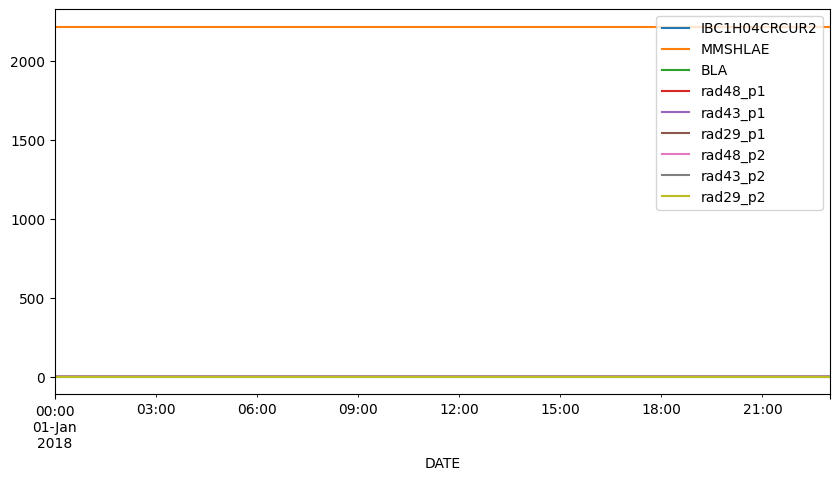

In [4]:
df.loc['2018-01-01'][['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad43_p1', 'rad29_p1', 'rad48_p2', 'rad43_p2', 'rad29_p2']].plot(figsize=[10, 5])
# df.loc['2017-01-01'][['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad48_p2', 'rad29_p2']].plot(figsize=[10, 5])
plt.legend(loc='upper right')

array([[<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>,
        <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>,
        <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>,
        <Axes: xlabel='DATE'>]], dtype=object)

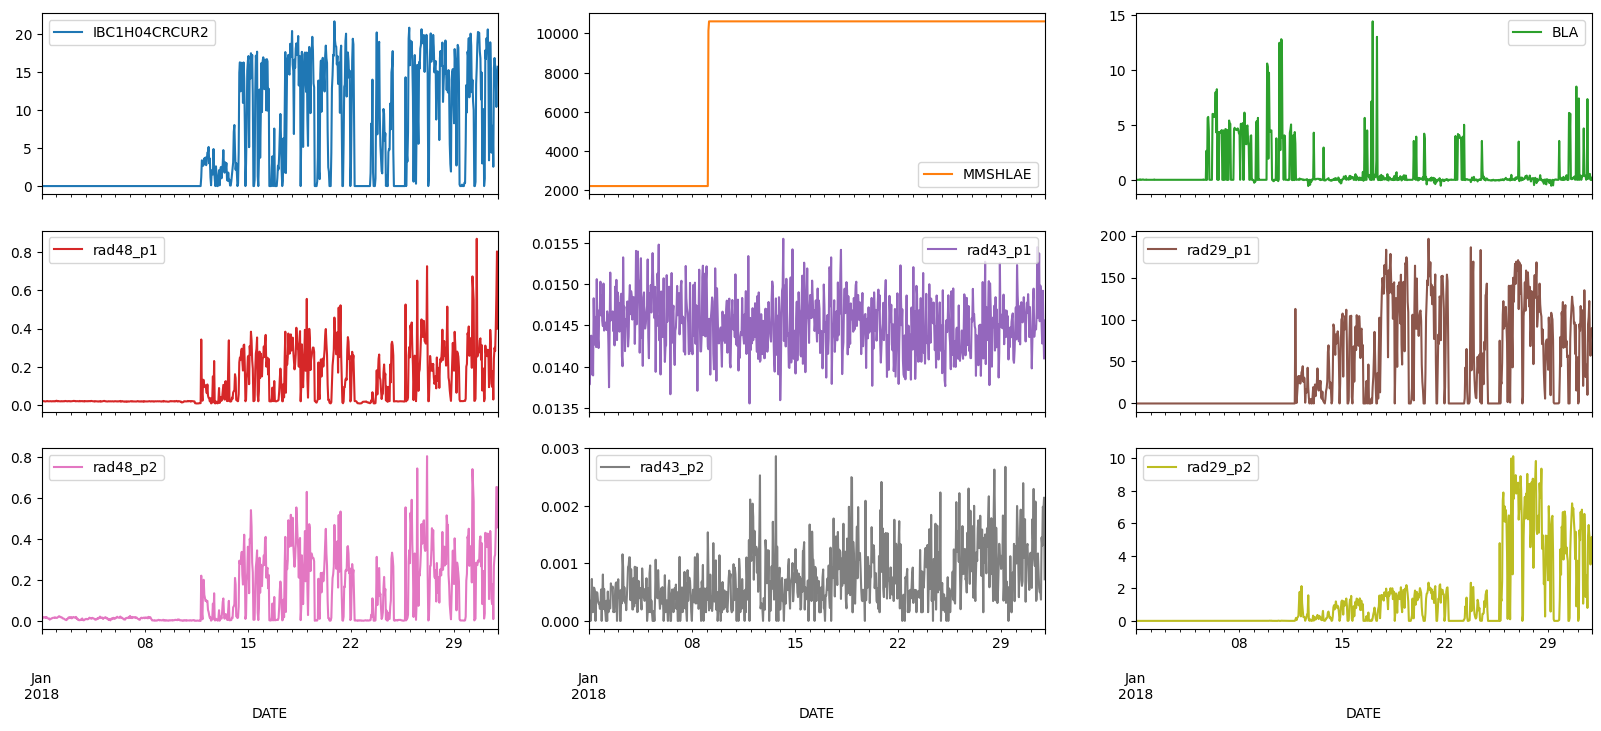

In [5]:
df.loc['2018-01'][['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad43_p1', 'rad29_p1', 'rad48_p2', 'rad43_p2', 'rad29_p2']].plot(subplots=True, layout=(3, 3), figsize=(20, 8))
# df.loc['2017-01'][['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad48_p2', 'rad29_p2']].plot(subplots=True, layout=(2, 3), figsize=(20, 8))

In [8]:
# mSTAMP calculates the multivariate matrix profile
m=96 # Window length
mpx, indices = stumpy.mstump(df[['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p2', 'rad43_p2', 'rad29_p2']], m=m)

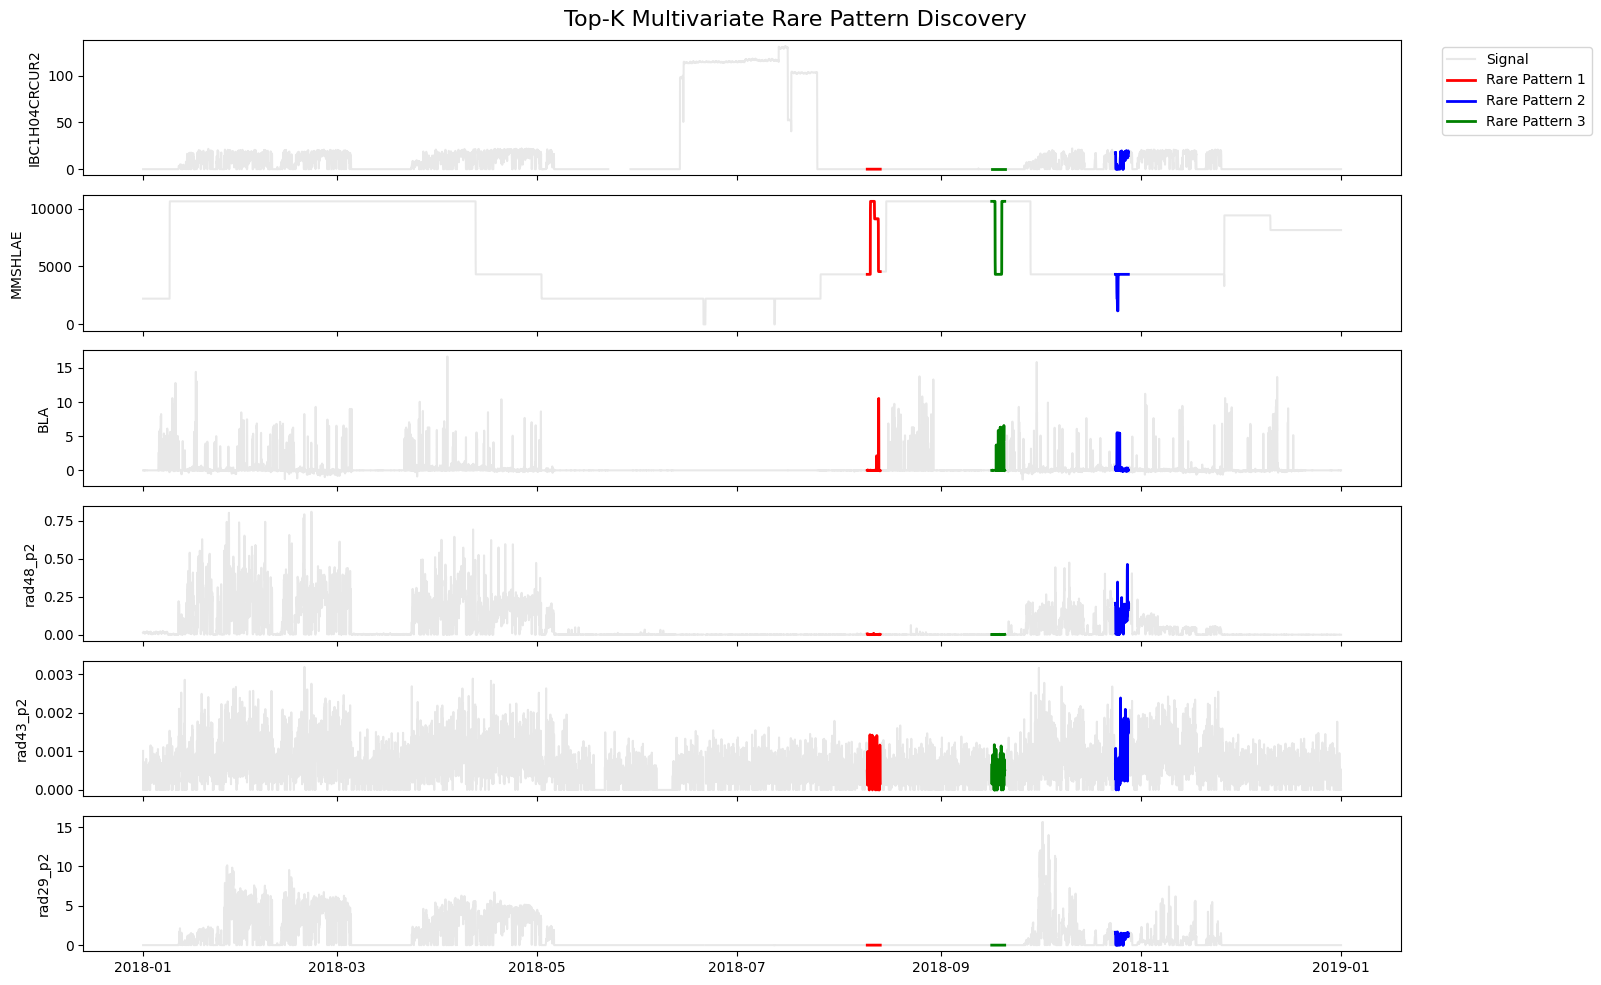

In [9]:
# 1. Identify the Top 3 Rarest Patterns (Discords)
# We use an exclusion zone (m) so we don't pick overlapping windows
k = 3   # Number of patterns to find
mpx_values = mpx[0].copy()
discord_indices = []

for _ in range(k):
    idx = np.argmax(mpx_values)
    discord_indices.append(idx)
    # Mask out the area around this discord so we find a DIFFERENT rare pattern next
    start = max(0, idx - m)
    end = min(len(mpx_values), idx + m)
    mpx_values[start:end] = -1  # Set to low value so it's not picked again

# 2. Plotting the results
fig, axes = plt.subplots(6, 1, figsize=(16, 10), sharex=True)
cols = ['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p2', 'rad43_p2', 'rad29_p2']
colors = ['red', 'blue', 'green'] # One color per rare pattern

for i, col_name in enumerate(cols):
    # Plot the background data
    axes[i].plot(df.index, df[col_name], color='lightgray', alpha=0.5, label='Signal')
    
    # Highlight each of the Top-K discords
    for j, d_idx in enumerate(discord_indices):
        pattern_segment = df.iloc[d_idx : d_idx + m]
        axes[i].plot(pattern_segment.index, pattern_segment[col_name], 
                     color=colors[j], linewidth=2, 
                     label=f'Rare Pattern {j+1}' if i == 0 else "")
    
    axes[i].set_ylabel(col_name)
    if i == 0:
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.suptitle('Top-K Multivariate Rare Pattern Discovery', fontsize=16)
plt.tight_layout()
plt.show()